## Imports

In [ ]:
import os, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from time import time

# Preprocessing & feature selection
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import LocalOutlierFactor

# Model selection
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import recall_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Causal learning
from itertools import combinations
from sklearn.multiclass import OneVsRestClassifier

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

print("All imports loaded.")

All imports loaded.


## Data Exploration and Analysis

In [7]:
df = pd.read_csv('train.csv')

target_col = "cancer"
id_col = "id"

y = df[target_col]
X = df.drop(columns=[id_col, target_col])

# Map cancer labels to names for better interpretability
label_map = {1: "GBM", 2: "LUSC", 3: "OV"}
y_named = y.map(label_map)

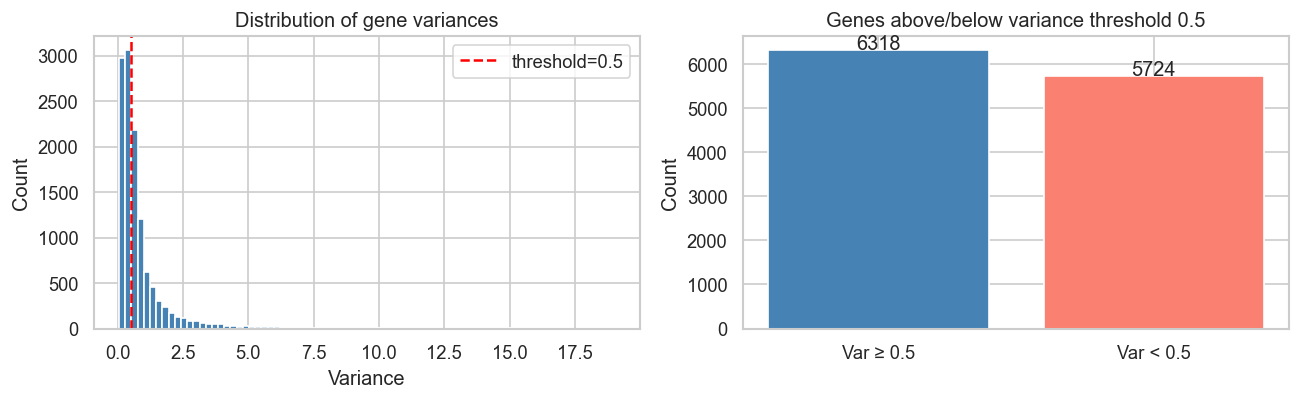

Genes with var < 0.5: 5724 / 12042


In [8]:
# Feature variance distribution

variances = X.var().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(variances, bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of gene variances")
axes[0].set_xlabel("Variance"); axes[0].set_ylabel("Count")
axes[0].axvline(0.5, color="red", ls="--", label="threshold=0.5")
axes[0].legend()

low_var = (variances < 0.5).sum()

axes[1].bar(["Var ≥ 0.5", "Var < 0.5"], [len(variances) - low_var, low_var], color=["steelblue", "salmon"])
axes[1].set_title(f"Genes above/below variance threshold 0.5")
axes[1].set_ylabel("Count")

for i, v in enumerate([len(variances) - low_var, low_var]):
    axes[1].text(i, v + 30, str(v), ha="center")

plt.tight_layout()
plt.show()
print(f"Genes with var < 0.5: {low_var} / {len(variances)}")

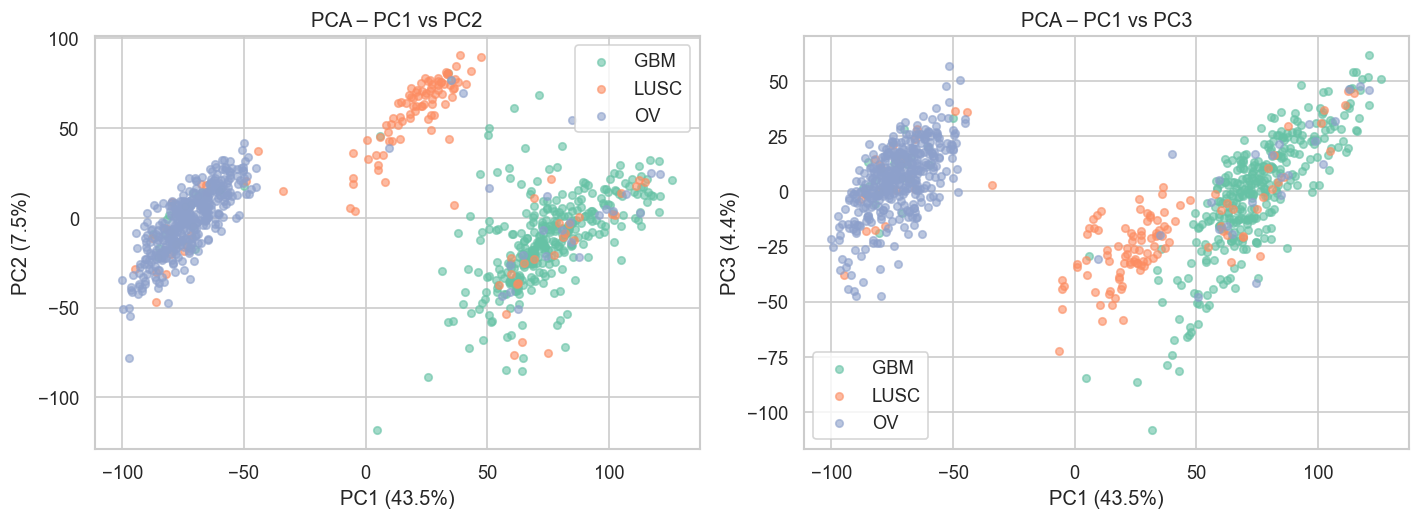

Variance explained by 3 pricipal components: 55.3%


In [9]:
# PCA – 2D scatter colored by cancer type

scaler_eda = StandardScaler()
X_scaled = scaler_eda.fit_transform(X)
pca_eda = PCA(n_components=3, random_state=42)
X_pca = pca_eda.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, name in label_map.items():
    mask = y == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.6, s=20)

axes[0].set_xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca_eda.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA – PC1 vs PC2")
axes[0].legend()

for label, name in label_map.items():
    mask = y == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2], label=name, alpha=0.6, s=20)

axes[1].set_xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC3 ({pca_eda.explained_variance_ratio_[2]:.1%})")
axes[1].set_title("PCA – PC1 vs PC3")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Variance explained by 3 pricipal components: {pca_eda.explained_variance_ratio_.sum():.1%}")

## Data Preprocessing

In [10]:
# Train test split for Holdout acuracy estimation

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
# Variance threshold filtering (fit on train only) + StandardScaler

vt = VarianceThreshold(threshold=0.5)
X_train_vt = vt.fit_transform(X_train)
X_val_vt   = vt.transform(X_val)
kept_genes = X_train.columns[vt.get_support()].tolist()
print(f"Genes kept after VarianceThreshold(0.5): {X_train_vt.shape[1]}  "
      f"(removed {X_train.shape[1] - X_train_vt.shape[1]})")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_vt)
X_val_sc   = scaler.transform(X_val_vt)
print(f"Scaled training set shape: {X_train_sc.shape}")

Genes kept after VarianceThreshold(0.5): 6318  (removed 5724)
Scaled training set shape: (708, 6318)


## Dimensionality Reduction Comparisons

In [13]:
pca_full = PCA(random_state=42).fit(X_train_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95 = int(np.searchsorted(cumvar, 0.95) + 1)

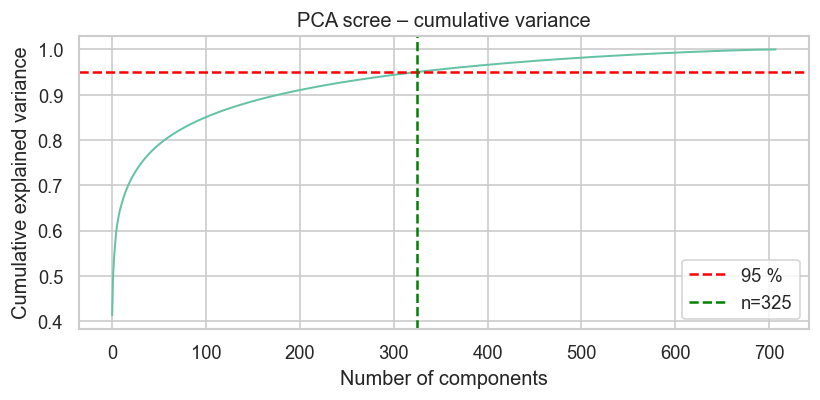

Components for 95% variance: 325


In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(cumvar, linewidth=1.2)
ax.axhline(0.95, color="red", ls="--", label="95 %")
ax.axvline(n95, color="green", ls="--", label=f"n={n95}")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA scree – cumulative variance")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Components for 95% variance: {n95}")

In [ ]:
# Compare feature-set strategies via 5-fold CV for the LogisticRegression baseline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_lr = LogisticRegression(max_iter=2000, solver="saga", random_state=42)
strategies = {}

# Strategy 1: PCA 95%
pca95 = PCA(n_components=n95, random_state=42)
X_pca95 = pca95.fit_transform(X_train_sc)
t0 = time()
res = cross_validate(base_lr, X_pca95, y_train, cv=cv, scoring="accuracy", return_train_score=True)
strategies["PCA-95%"] = {
    "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
    "train": res["train_score"].mean(), "time": time()-t0, "n_feats": n95
}

# Strategy 2: PCA 50 components (compact)
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(X_train_sc)
t0 = time()
res = cross_validate(base_lr, X_pca50, y_train, cv=cv, scoring="accuracy", return_train_score=True)
strategies["PCA-50"] = {
    "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
    "train": res["train_score"].mean(), "time": time()-t0, "n_feats": 50
}

# Strategy 3: ANOVA top-50
skb50 = SelectKBest(f_classif, k=50).fit(X_train_sc, y_train)
X_anova50 = skb50.transform(X_train_sc)
t0 = time()
res = cross_validate(base_lr, X_anova50, y_train, cv=cv, scoring="accuracy", return_train_score=True)
strategies["ANOVA-50"] = {
    "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
    "train": res["train_score"].mean(), "time": time()-t0, "n_feats": 50
}

# Strategy 3: ANOVA top-20
skb20 = SelectKBest(f_classif, k=20).fit(X_train_sc, y_train)
X_anova20 = skb20.transform(X_train_sc)
t0 = time()
res = cross_validate(base_lr, X_anova20, y_train, cv=cv, scoring="accuracy", return_train_score=True)
strategies["ANOVA-20"] = {
    "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
    "train": res["train_score"].mean(), "time": time()-t0, "n_feats": 20
}

# Strategy 4: ANOVA top-1000
skb1000 = SelectKBest(f_classif, k=1000).fit(X_train_sc, y_train)
X_anova1000 = skb1000.transform(X_train_sc)
t0 = time()
res = cross_validate(base_lr, X_anova1000, y_train, cv=cv, scoring="accuracy", return_train_score=True)
strategies["ANOVA-1000"] = {
    "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
    "train": res["train_score"].mean(), "time": time()-t0, "n_feats": 1000
}

# Strategy 5: ANOVA top-100
skb100 = SelectKBest(f_classif, k=100).fit(X_train_sc, y_train)
X_anova100 = skb100.transform(X_train_sc)
t0 = time()
res = cross_validate(base_lr, X_anova100, y_train, cv=cv, scoring="accuracy", return_train_score=True)
strategies["ANOVA-100"] = {
    "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
    "train": res["train_score"].mean(), "time": time()-t0, "n_feats": 100
}

## this takes a long time to run this is why it is commentedd out
# Strategy 6: All 6318 genes (no reduction)
# t0 = time()
# res = cross_validate(base_lr, X_train_sc, y_train, cv=cv, scoring="accuracy", return_train_score=True)
# strategies["All-6318"] = {
#     "mean_cv": res["test_score"].mean(), "std_cv": res["test_score"].std(),
#     "train": res["train_score"].mean(), "time": time()-t0, "n_feats": 6318
# }

strat_df = pd.DataFrame(strategies).T.sort_values("mean_cv", ascending=False)
strat_df["mean_cv"] = strat_df["mean_cv"].map("{:.4f}".format)
strat_df["std_cv"]  = strat_df["std_cv"].map("{:.4f}".format)
strat_df["train"]   = strat_df["train"].map("{:.4f}".format)
strat_df["time"]    = strat_df["time"].map("{:.1f}s".format)
print(strat_df.to_string())

           mean_cv  std_cv   train   time  n_feats
ANOVA-50    0.8941  0.0182  0.9071   0.8s     50.0
ANOVA-20    0.8927  0.0179  0.9040   0.2s     20.0
ANOVA-1000  0.8828  0.0179  1.0000  61.7s   1000.0
ANOVA-100   0.8715  0.0248  0.9357   3.9s    100.0
PCA-50      0.8616  0.0210  0.9018   4.2s     50.0
PCA-95%     0.8080  0.0221  1.0000  39.9s    325.0


In [18]:
# More detailed view at the lower numbers of anova params

anova_pipe = Pipeline([('anova', SelectKBest(f_classif)), ('model', base_lr)])
param_grid = {'anova__k':[1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]}
grid_search = GridSearchCV(anova_pipe, param_grid, cv=cv, scoring="accuracy", return_train_score=True, n_jobs=-1)

grid_search.fit(X_train_sc, y_train)
results = pd.DataFrame(grid_search.cv_results_)

# Keep only the columns we care about
summary = results[['param_anova__k', 'mean_test_score', 'std_test_score', 'mean_train_score', 'mean_fit_time']]
summary = summary.rename(columns={'param_anova__k': 'k_features', 'mean_test_score': 'mean_cv', 'std_test_score': 'std_cv', 'mean_train_score': 'train'})
summary = summary.sort_values('k_features').set_index('k_features')

print(summary.round(4))
print(f"\n The best number of features is: {grid_search.best_params_['anova__k']} (CV Score: {grid_search.best_score_:.4f})")

            mean_cv  std_cv   train  mean_fit_time
k_features                                        
1            0.8122  0.0181  0.8129         0.3598
2            0.8404  0.0261  0.8429         0.3332
3            0.8588  0.0266  0.8612         0.4058
4            0.8785  0.0191  0.8771         0.3235
5            0.8899  0.0220  0.8863         0.3411
10           0.8927  0.0223  0.8965         0.3919
15           0.8927  0.0179  0.9029         0.4094
20           0.8955  0.0227  0.9022         0.4311
25           0.8899  0.0162  0.9043         0.4830
30           0.8899  0.0179  0.9040         0.4990
40           0.8856  0.0172  0.9075         0.5557
50           0.8885  0.0194  0.9100         0.5636

 The best number of features is: 20 (CV Score: 0.8955)


## Model Training & Comparison (ANOVA-100)
Bigger dataset was choosen here to have a more stable model wrt to noise in the training data (which exists according to the task description in the form of mislabeling)

In [ ]:
models = {
    "LogReg":    LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42),
    "LinearSVC": LinearSVC(max_iter=5000, dual=True, random_state=42),
    "SVM-RBF":   SVC(kernel="rbf", random_state=42),
    "RF":        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "HistGBT":   HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=42),
    "KNN-7":     KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

results = []
for m_name, m in models.items():
    t0 = time()
    cv_res = cross_validate(
        m, X_anova100, y_train, cv=cv, scoring="accuracy",
        return_train_score=True
    )
    elapsed = time() - t0
    results.append({
        "model":      m_name,
        "cv_mean":    cv_res["test_score"].mean(),
        "cv_std":     cv_res["test_score"].std(),
        "train_mean": cv_res["train_score"].mean(),
        "time_s":     elapsed,
    })
    print(f"  {m_name:<12} CV={cv_res['test_score'].mean():.4f} ± {cv_res['test_score'].std():.4f}  "
          f"train={cv_res['train_score'].mean():.4f}  ({elapsed:.1f}s)")

res_df = pd.DataFrame(results).sort_values("cv_mean", ascending=False)
print("\n Results (ANOVA-100, sorted by CV accuracy)")
print(res_df.to_string(index=False))

  LogReg       CV=0.8715 ± 0.0248  train=0.9354  (0.6s)
  LinearSVC    CV=0.8545 ± 0.0359  train=0.9520  (4.8s)
  SVM-RBF      CV=0.9054 ± 0.0237  train=0.9054  (0.3s)
  RF           CV=0.9012 ± 0.0212  train=1.0000  (9.3s)
  HistGBT      CV=0.9012 ± 0.0217  train=1.0000  (15.9s)
  KNN-7        CV=0.9054 ± 0.0237  train=0.9050  (0.6s)

── Results (ANOVA-100, sorted by CV accuracy) ──
    model  cv_mean   cv_std  train_mean    time_s
    KNN-7 0.905404 0.023693    0.905017  0.627820
  SVM-RBF 0.905404 0.023693    0.905370  0.336071
       RF 0.901169 0.021204    1.000000  9.265256
  HistGBT 0.901169 0.021673    1.000000 15.882419
   LogReg 0.871511 0.024813    0.935383  0.578186
LinearSVC 0.854530 0.035896    0.951978  4.842387


In [ ]:
# Hyperparameter tuning for top-3 models on ANOVA-100

param_grids = {
    "SVM-RBF": (SVC(random_state=42), {
        "C": [0.1, 1, 10, 50, 100],
        "gamma": ["scale", "auto", 0.01, 0.001],
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
    }),
    "RF": (RandomForestClassifier(random_state=42, n_jobs=-1), {
        "n_estimators": [200, 400],
        "max_depth": [None, 20, 30],
        "max_features": ["sqrt", "log2"],
    }),
}

best_models = {}
for name, (est, params) in param_grids.items():
    gs = GridSearchCV(est, params, cv=cv, scoring="accuracy", n_jobs=-1, refit=True)
    gs.fit(X_anova100, y_train)
    best_models[name] = gs.best_estimator_
    print(f"{name:>8}  best CV={gs.best_score_:.4f}  params={gs.best_params_}")

 SVM-RBF  best CV=0.9054  params={'C': 1, 'gamma': 'scale'}
     KNN  best CV=0.9054  params={'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
      RF  best CV=0.9040  params={'max_depth': None, 'max_features': 'log2', 'n_estimators': 400}

Done tuning.


## Hold out Evaluation

In [21]:
X_val_anova100 = skb100.transform(X_val_sc)

print("Hold-out accuracy (178 samples):\n")
for name, model in best_models.items():
    y_pred = model.predict(X_val_anova100)
    acc = accuracy_score(y_val, y_pred)
    print(f"  {name:<10}  accuracy = {acc:.4f}")

best_name = max(best_models, key=lambda n: accuracy_score(y_val, best_models[n].predict(X_val_anova100)))
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_val_anova100)

print(f"\n→ Best model on hold-out: {best_name}  "
      f"(accuracy = {accuracy_score(y_val, y_pred_best):.4f})")

Hold-out accuracy (178 samples):

  SVM-RBF     accuracy = 0.8820
  KNN         accuracy = 0.8820
  RF          accuracy = 0.8820

→ Best model on hold-out: SVM-RBF  (accuracy = 0.8820)


Note that all model achive the same hold out accuracy after hyperparameter tuning, choosing SVM-RMF for now for its inherent roboustness againt noise in the data


Analyzed model: SVM-RBF

              precision    recall  f1-score   support

         GBM       0.89      0.89      0.89        70
        LUSC       0.89      0.65      0.76        26
          OV       0.88      0.95      0.91        82

    accuracy                           0.88       178
   macro avg       0.89      0.83      0.85       178
weighted avg       0.88      0.88      0.88       178



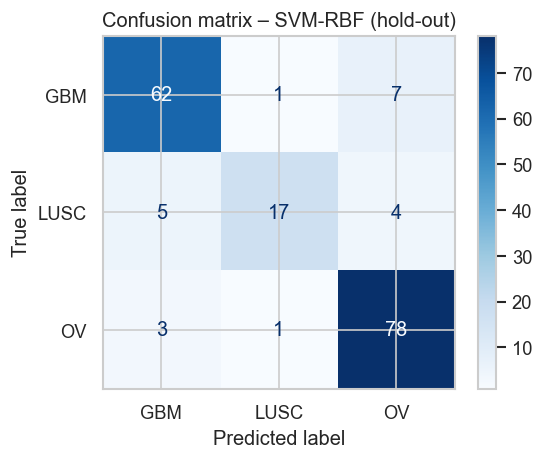

In [25]:
print(f"Analyzed model: {best_name}\n")
print(classification_report(y_val, y_pred_best, target_names=["GBM", "LUSC", "OV"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_best,
    display_labels=["GBM", "LUSC", "OV"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Confusion matrix – {best_name} (hold-out)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
df_t = pd.read_csv("test.csv")
patient_ids = df_t[id_col].astype(str).reset_index(drop=True)
def prediction_summary(row):
    top3 = row.sort_values(ascending=False).head(3)
    labels = top3.index.tolist()
    probs = (100 * top3.values).round(1)

    parts = [f"predicted {labels[0]} with {probs[0]:.1f}%"]
    if len(labels) > 1:
        parts.append(f"followed by prediction of {labels[1]} with {probs[1]:.1f}%")
    if len(labels) > 2:
        parts.append(f"and {labels[2]} with {probs[2]:.1f}%")

    return f"Patient[{patient_ids.iloc[row.name]}]: " + ", ".join(parts) + "."

svm_indep = OneVsRestClassifier(
    CalibratedClassifierCV(
        estimator=SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
        method="sigmoid",
        cv=5
    )
)
svm_indep.fit(X_anova100, y_train)
y_t = df_t[target_col]
X_t = df_t.drop(columns=[id_col, target_col])
X_t_vt = vt.transform(X_t)
X_t_sc = scaler.transform(X_t_vt)
X_t_anova100 = skb100.transform(X_t_sc)
indep_probs = np.column_stack([
    est.predict_proba(X_t_anova100)[:, 1]  # P(positive class) per binary model
    for est in svm_indep.estimators_
])
indep_cols = [label_map[c] for c in svm_indep.classes_]
indep_df   = pd.DataFrame(indep_probs, columns=indep_cols)
score_ = pd.DataFrame(
    indep_probs, columns = indep_cols
)
indep_table = pd.DataFrame({
    "true_class"      : y_t.map(label_map).values,
    "predicted_class" : indep_df.idxmax(axis=1),
    "confidence_pct"  : (100 * indep_df.max(axis=1)).round(1)
})
indep_table = pd.concat([indep_table, (100 * indep_df).round(1)], axis=1)
indep_table.insert(
    6,
    "prediction_summary",
    score_.apply(prediction_summary, axis=1)
)
indep_table.head()


## Summary (part 1)

| Step | Detail |
|------|--------|
| **Data** | 886 samples × 12,042 genes; 3 classes: GBM (348), LUSC (130), OV (408) |
| **Preprocessing** | Variance filter (threshold 0.5) → 6,318 genes → StandardScaler |
| **Feature selection** | ANOVA F-test top-100 genes (best speed/accuracy trade-off) |
| **Best feature-set** | ANOVA-100: 87.2% CV accuracy with LogReg baseline |
| **Model comparison** | SVM-RBF & KNN tied at **90.5% CV**, RF close at 90.1% |
| **Tuned best model** | **SVM-RBF** (C=1, gamma=scale) — **88.2% hold-out accuracy** |
| **LUSC recall** | 65% — the minority class is hardest to classify (overlaps GBM in PC space) |
| **Top genes** | GFAP (brain marker → GBM), WFDC2 (OV marker), PTPRZ1 (GBM), DMN |


What comes next? We try to further improve the model understand the data better and get more explainability using basic causal learning

In [42]:
# Core DGP diagnostics 

# Sample-level QC and outlier flags
sample_qc_df = pd.DataFrame({
    "id": df[id_col].values,
    "cancer": y.values,
    "sample_mean": X.mean(axis=1).values,
    "sample_std": X.std(axis=1).values,
    "sample_iqr": (X.quantile(0.75, axis=1) - X.quantile(0.25, axis=1)).values,
})

X_scaled = StandardScaler().fit_transform(X)
lof = LocalOutlierFactor(n_neighbors=25, contamination=0.05) # contamination is a free hyperparameter
lof_pred = lof.fit_predict(PCA(n_components=20, random_state=42).fit_transform(X_scaled))
sample_qc_df["outlier_flag"] = (lof_pred == -1)

# PCA + class attribution + residual structure
y_onehot = pd.get_dummies(y.astype(str), drop_first=False)
pca20 = PCA(n_components=20, random_state=42).fit(X_scaled)
Z = pca20.transform(X_scaled)
class_var = 0.0
for j in range(20):
    lr = LinearRegression().fit(y_onehot, Z[:, j])
    class_var += pca20.explained_variance_ratio_[j] * lr.score(y_onehot, Z[:, j])

X_fit = np.zeros_like(X_scaled)
for j in range(X_scaled.shape[1]):
    lrj = LinearRegression().fit(y_onehot, X_scaled[:, j])
    X_fit[:, j] = lrj.predict(y_onehot)
X_resid = X_scaled - X_fit
resid_var10 = PCA(n_components=10, random_state=42).fit(X_resid).explained_variance_ratio_.sum()

dgp_core = pd.DataFrame([
    ["Top-20 latent variance", pca20.explained_variance_ratio_.sum()],
    ["Class-attributable latent variance", class_var],
    ["Residual top-10 variance", resid_var10],
], columns=["metric", "value"])

display(dgp_core)

,metric,value
0,Top-20 latent variance,0.705021
1,Class-attributable latent variance,0.337047
2,Residual top-10 variance,0.477430


We want to guess the miss labled parts of our data to use for being potentially able to identify missclassification by doctors

In [43]:
# OOF label-flip detection

flip_pipe = Pipeline([
    ("vt", VarianceThreshold(threshold=0.5)),
    ("sc", StandardScaler()),
    ("anova", SelectKBest(f_classif, k=100)),
    # probability=True is required for cross_val_predict(..., method='predict_proba').
    ("clf", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)),
])

cv_flip = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_oof = cross_val_predict(flip_pipe, X, y.values, cv=cv_flip, method="predict_proba", n_jobs=-1)
classes_ = np.sort(y.unique())
pred_idx = np.argmax(proba_oof, axis=1)
pred_oof = classes_[pred_idx]

y_idx = np.array([np.where(classes_ == t)[0][0] for t in y.values])
p_true = proba_oof[np.arange(len(y)), y_idx]
p_best = proba_oof[np.arange(len(y)), pred_idx]

flip_candidates = pd.DataFrame({
    "id": df[id_col].values,
    "observed": y.values,
    "pred": pred_oof,
    "p_observed": p_true,
    "p_pred": p_best,
    "is_disagreement": (pred_oof != y.values),
})

In [44]:
# Conservative and strict variants
flip_candidates["flag_conservative"] = (
    flip_candidates["is_disagreement"] &
    (flip_candidates["p_pred"] >= 0.85) &
    (flip_candidates["p_observed"] <= 0.10)
)
flip_candidates["flag_strict"] = (
    flip_candidates["is_disagreement"] &
    (flip_candidates["p_pred"] >= 0.92) &
    (flip_candidates["p_observed"] <= 0.05)
)

In [47]:
flag_summary = pd.DataFrame([
    ["OOF disagreements", int(flip_candidates["is_disagreement"].sum())],
    ["Conservative flags", int(flip_candidates["flag_conservative"].sum())],
    ["Strict flags", int(flip_candidates["flag_strict"].sum())],
], columns=["item", "count"])

display(flag_summary)
display(flip_candidates.loc[flip_candidates["flag_conservative"]].head(10))

,item,count
0,OOF disagreements,88
1,Conservative flags,74
2,Strict flags,7


,id,observed,pred,p_observed,p_pred,is_disagreement,flag_conservative,flag_strict
12,S4340376,2,3,0.045991,0.911841,True,True,False
15,S5437754,2,1,0.038947,0.897841,True,True,False
19,S1033242,1,3,0.034614,0.909350,True,True,False
38,S6299924,2,1,0.084500,0.867962,True,True,False
51,S4473459,2,1,0.097407,0.853330,True,True,False
55,S3761617,2,3,0.043392,0.919575,True,True,False
83,S7916949,2,1,0.055884,0.888448,True,True,False
84,S8524432,2,3,0.071046,0.902609,True,True,False
93,S0064003,2,1,0.082973,0.863493,True,True,False
95,S4052510,1,3,0.025701,0.921566,True,True,True


In [48]:
# Label-cleaning benchmark

y_clean_cons = y.copy().astype(int)
idx_cons = flip_candidates.index[flip_candidates["flag_conservative"]].to_numpy()
y_clean_cons.iloc[idx_cons] = flip_candidates.loc[idx_cons, "pred"].astype(int).values

y_clean_strict = y.copy().astype(int)
idx_strict = flip_candidates.index[flip_candidates["flag_strict"]].to_numpy()
y_clean_strict.iloc[idx_strict] = flip_candidates.loc[idx_strict, "pred"].astype(int).values

cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_orig = cross_val_score(flip_pipe, X, y.values, cv=cv_eval, scoring="accuracy", n_jobs=-1)
acc_cons = cross_val_score(flip_pipe, X, y_clean_cons.values, cv=cv_eval, scoring="accuracy", n_jobs=-1)
acc_strict = cross_val_score(flip_pipe, X, y_clean_strict.values, cv=cv_eval, scoring="accuracy", n_jobs=-1)

clean_benchmark = pd.DataFrame([
    ["Original", acc_orig.mean(), acc_orig.std(), 0],
    ["Conservative clean", acc_cons.mean(), acc_cons.std(), len(idx_cons)],
    ["Strict clean", acc_strict.mean(), acc_strict.std(), len(idx_strict)],
], columns=["label_set", "cv_acc_mean", "cv_acc_std", "n_relabels"]).sort_values("cv_acc_mean", ascending=False)

display(clean_benchmark)

,label_set,cv_acc_mean,cv_acc_std,n_relabels
1,Conservative clean,0.984200,0.005532,74
2,Strict clean,0.908582,0.016502,7
0,Original,0.900686,0.012094,0


In [1]:
best_policy = clean_benchmark.iloc[0]["label_set"]
if best_policy == "Conservative clean":
    y_final = y_clean_cons
elif best_policy == "Strict clean":
    y_final = y_clean_strict
else:
    y_final = y

final_model = Pipeline([
    ("vt", VarianceThreshold(threshold=0.5)),
    ("sc", StandardScaler()),
    ("anova", SelectKBest(f_classif, k=100)),
    ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
])
final_model.fit(X, y_final.values)

test_df = pd.read_csv("test.csv")
X_test = test_df.drop(columns=["id", target_col])
y_test_pred = final_model.predict(X_test)

submission_focus = pd.DataFrame({"id": test_df["id"], "cancer": y_test_pred})
submission_focus.to_csv("submission_focus_cleaned.csv", index=False)

NameError: name 'clean_benchmark' is not defined

In [50]:
sub_old = pd.read_csv("submission.csv").sort_values("id").reset_index(drop=True)
sub_new = pd.read_csv("submission_focus_cleaned.csv").sort_values("id").reset_index(drop=True)

print("Any ID changed?", (sub_old["id"] != sub_new["id"]).any())   # should be False
print("ID set equal?", set(sub_old["id"]) == set(sub_new["id"]))   # should be True

diff_labels = sub_old.merge(sub_new, on="id", suffixes=("_old", "_new"))
diff_labels = diff_labels[diff_labels["cancer_old"] != diff_labels["cancer_new"]]
print("Label differences:", len(diff_labels))
display(diff_labels.head(20))

Any ID changed? False
ID set equal? True
Label differences: 0


,id,cancer_old,cancer_new


Note that if we train our model on the cleaned data we get exactly the same prediction as before cleaning, for prediction the test data, demonstrating a very robust handling of noise in the training data

## Dive into Causal learning for better explainability

In [55]:
# Design contract + causal feature matrix
# Conservative causal framing: observational effect evidence, not intervention proof

causal_assumptions = pd.DataFrame([
    ["Estimand", "Gene -> cancer directional effect proxy via sparse linear log-odds model"],
    ["Data regime", "Observational only; no randomized intervention"],
    ["Confounding", "Partially controlled by VT+scaling+ANOVA selection; residual confounding possible"],
    ["Label noise", "Use cleaned labels selected by policy and report sensitivity"],
    ["Claim strength", "Associational-causal evidence tiering, not definitive mechanistic causation"],
], columns=["item", "statement"])


y_causal = y_final.copy() if "y_final" in globals() else y.copy()
vt_causal = VarianceThreshold(threshold=0.5)
X_vt_causal = vt_causal.fit_transform(X)
genes_vt = X.columns[vt_causal.get_support()]

sc_causal = StandardScaler()
X_sc_causal = sc_causal.fit_transform(X_vt_causal)

skb_causal = SelectKBest(f_classif, k=100)
X_causal = skb_causal.fit_transform(X_sc_causal, y_causal.values)
causal_genes = np.array(genes_vt)[skb_causal.get_support()]

display(causal_assumptions)
print(f"Causal matrix shape: {X_causal.shape}")
print(f"Using label set: {'y_final' if 'y_final' in globals() else 'y'}")

,item,statement
0,Estimand,Gene -> cancer directional effect proxy via sp...
1,Data regime,Observational only; no randomized intervention
2,Confounding,Partially controlled by VT+scaling+ANOVA selec...
3,Label noise,Use cleaned labels selected by policy and repo...
4,Claim strength,"Associational-causal evidence tiering, not def..."


Causal matrix shape: (886, 100)
Using label set: y_final


In [59]:
effect_clf = OneVsRestClassifier(
    LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.5,
        class_weight="balanced",
        max_iter=5000,
        random_state=42,
    )
)
effect_clf.fit(X_causal, y_causal.values)

causal_classes = effect_clf.classes_
coef_mat = np.vstack([est.coef_.ravel() for est in effect_clf.estimators_])

effect_df = pd.DataFrame(
    coef_mat.T,
    index=causal_genes,
    columns=[f"effect_class_{c}" for c in causal_classes],
).reset_index().rename(columns={"index": "gene"})

effect_df["mean_abs_effect"] = np.mean(np.abs(coef_mat.T), axis=1)
display(effect_df.sort_values("mean_abs_effect", ascending=False).head(5))

print("Effect model fitted (L1-sparse OvR logistic).")
print("Interpretation: positive coefficient => higher log-odds for that class, all else fixed.")

,gene,effect_class_1,effect_class_2,effect_class_3,mean_abs_effect
72,SOX17,0.000000,-1.732126,0.461505,0.731210
50,WT1,0.000000,-0.948957,1.191686,0.713548
60,C1QL1,0.481778,-1.562162,0.000000,0.681313
27,ACTN2,1.102866,-0.427220,-0.411491,0.647192
61,DST,0.000000,1.476855,-0.304883,0.593913


Effect model fitted (L1-sparse OvR logistic).
Interpretation: positive coefficient => higher log-odds for that class, all else fixed.


In [61]:
# Bootstrap CIs + empirical p-values + FDR

rng = np.random.default_rng(42)

B = 250
n = X_causal.shape[0]
n_classes = len(causal_classes)
n_genes = len(causal_genes)

boot_coefs = np.zeros((B, n_classes, n_genes), dtype=float)

for b in range(B):
    idx_b = rng.choice(n, n, replace=True)
    Xb = X_causal[idx_b]
    yb = y_causal.values[idx_b]

    boot_model = OneVsRestClassifier(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.5,
            class_weight="balanced",
            max_iter=2000,
            tol=1e-3,
            random_state=42,
        ),
        n_jobs=1,
    )
    boot_model.fit(Xb, yb)
    boot_coefs[b] = np.vstack([est.coef_.ravel() for est in boot_model.estimators_])

    if (b + 1) % 20 == 0 or (b + 1) == B:
        print(f"Bootstrap progress: {b + 1}/{B}")

coef_mean = boot_coefs.mean(axis=0)
coef_lo = np.percentile(boot_coefs, 2.5, axis=0)
coef_hi = np.percentile(boot_coefs, 97.5, axis=0)
sign_stability = np.mean(np.sign(boot_coefs) == np.sign(coef_mean[None, :, :]), axis=0)

p_emp = 2 * np.minimum((boot_coefs <= 0).mean(axis=0), (boot_coefs >= 0).mean(axis=0))
p_flat = p_emp.ravel()

# Benjamini-Hochberg FDR (manual implementation, no extra dependency).
m = len(p_flat)
order = np.argsort(p_flat)
p_sorted = p_flat[order]
q_sorted = p_sorted * m / (np.arange(m) + 1)
q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
q_flat = np.empty_like(q_sorted)
q_flat[order] = np.clip(q_sorted, 0, 1)
q_emp = q_flat.reshape(p_emp.shape)

causal_effect_rows = []
for ci, c in enumerate(causal_classes):
    for gi, g in enumerate(causal_genes):
        causal_effect_rows.append({
            "class": int(c),
            "gene": g,
            "effect": float(coef_mean[ci, gi]),
            "ci_low": float(coef_lo[ci, gi]),
            "ci_high": float(coef_hi[ci, gi]),
            "p_emp": float(p_emp[ci, gi]),
            "q_bh": float(q_emp[ci, gi]),
            "sign_stability": float(sign_stability[ci, gi]),
        })

causal_effects_df = pd.DataFrame(causal_effect_rows)
causal_effects_df["abs_effect"] = causal_effects_df["effect"].abs()
causal_effects_df["is_robust"] = (
    (causal_effects_df["q_bh"] <= 0.10) &
    (causal_effects_df["sign_stability"] >= 0.90) &
    ~((causal_effects_df["ci_low"] <= 0) & (causal_effects_df["ci_high"] >= 0))
)

top_per_class = (
    causal_effects_df
    .sort_values(["class", "abs_effect"], ascending=[True, False])
    .groupby("class", as_index=False)
    .head(12)
)

display(top_per_class[["class", "gene", "effect", "ci_low", "ci_high", "q_bh", "sign_stability", "is_robust"]])
print(f"Bootstrap reps: {B}")
print(f"Robust effects discovered: {int(causal_effects_df['is_robust'].sum())} / {len(causal_effects_df)}")

Bootstrap progress: 20/250
Bootstrap progress: 40/250
Bootstrap progress: 60/250
Bootstrap progress: 80/250
Bootstrap progress: 100/250
Bootstrap progress: 120/250
Bootstrap progress: 140/250
Bootstrap progress: 160/250
Bootstrap progress: 180/250
Bootstrap progress: 200/250
Bootstrap progress: 220/250
Bootstrap progress: 240/250
Bootstrap progress: 250/250


,class,gene,effect,ci_low,ci_high,q_bh,sign_stability,is_robust
45,1,ABBA.1,0.864564,0.000000,1.811147,1.00,0.852,False
27,1,ACTN2,0.735017,0.000000,2.024629,1.00,0.928,False
51,1,LAT2,0.684616,0.029001,1.281352,1.00,0.988,False
69,1,FOXG1,0.587710,0.000000,1.912383,1.00,0.792,False
35,1,NLRP1,0.492689,0.000000,1.002943,1.00,0.960,False
42,1,TACSTD2,-0.479570,-1.030961,-0.040054,1.00,0.980,False
15,1,CNR1,0.406772,0.000000,1.305456,1.00,0.824,False
60,1,C1QL1,0.372383,0.000000,1.241308,1.00,0.732,False
54,1,CCDC103,0.311994,0.000000,0.725618,1.00,0.944,False
57,1,GFAP,0.283519,0.000000,0.667762,1.00,0.880,False


Bootstrap reps: 250
Robust effects discovered: 3 / 300


In [62]:
# Improved invariance check using class-balanced envs

pca_env = PCA(n_components=2, random_state=42).fit_transform(X_causal)
env_df = pd.DataFrame({
    "pc1": pca_env[:, 0],
    "class": y_causal.values,
})

env_df["pc1_within_class_centered"] = env_df["pc1"] - env_df.groupby("class")["pc1"].transform("median")
env_df["env_id"] = (env_df["pc1_within_class_centered"] >= 0).astype(int)

panel_genes = (
    causal_effects_df.sort_values("abs_effect", ascending=False)["gene"].drop_duplicates().head(20).tolist()
)
panel_idx = [np.where(causal_genes == g)[0][0] for g in panel_genes]

global_panel = coef_mean[:, panel_idx]
invariance_rows = []

for e in sorted(env_df["env_id"].unique()):
    idx_e = np.where(env_df["env_id"].values == e)[0]
    Xe = X_causal[idx_e][:, panel_idx]
    ye = y_causal.values[idx_e]

    if len(np.unique(ye)) < len(causal_classes) or len(idx_e) < 200:
        continue

    env_model = OneVsRestClassifier(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.5,
            class_weight="balanced",
            max_iter=2000,
            tol=1e-3,
            random_state=42,
        ),
        n_jobs=1,
    )
    env_model.fit(Xe, ye)

    env_coef_rows = []
    for est in env_model.estimators_:
        if hasattr(est, "coef_"):
            env_coef_rows.append(est.coef_.ravel())
        else:
            env_coef_rows.append(np.zeros(len(panel_idx), dtype=float))
    env_coef = np.vstack(env_coef_rows)

    sign_agree = float((np.sign(env_coef) == np.sign(global_panel)).mean())
    mag_ratio = float((np.abs(env_coef).mean() + 1e-9) / (np.abs(global_panel).mean() + 1e-9))

    rank_corrs = []
    for ci in range(env_coef.shape[0]):
        r1 = pd.Series(env_coef[ci]).rank().values
        r2 = pd.Series(global_panel[ci]).rank().values
        rank_corrs.append(np.corrcoef(r1, r2)[0, 1])
    mean_rank_corr = float(np.nanmean(rank_corrs))

    invariance_rows.append({
        "env_id": int(e),
        "n_samples": int(len(idx_e)),
        "n_unique_classes": int(np.unique(ye).size),
        "sign_agreement": sign_agree,
        "magnitude_ratio": mag_ratio,
        "rank_corr": mean_rank_corr,
    })

invariance_df = pd.DataFrame(invariance_rows).sort_values("env_id")
display(invariance_df)

if len(invariance_df):
    print(f"Mean sign agreement: {invariance_df['sign_agreement'].mean():.3f}")
    print(f"Mean |magnitude_ratio-1|: {np.abs(invariance_df['magnitude_ratio'] - 1).mean():.3f}")
    print(f"Mean rank correlation: {invariance_df['rank_corr'].mean():.3f}")

print("Interpretation:")
print("- sign_agreement close to 1.0 => stable effect direction")
print("- magnitude_ratio near 1.0 => stable effect size")
print("- rank_corr close to 1.0 => stable feature importance ordering")

,env_id,n_samples,n_unique_classes,sign_agreement,magnitude_ratio,rank_corr
0,0,442,3,0.416667,0.761731,0.688416
1,1,444,3,0.516667,0.899768,0.831005


Mean sign agreement: 0.467
Mean |magnitude_ratio-1|: 0.169
Mean rank correlation: 0.760
Interpretation:
- sign_agreement close to 1.0 => stable effect direction
- magnitude_ratio near 1.0 => stable effect size
- rank_corr close to 1.0 => stable feature importance ordering


In [64]:
# Consensus panel + causal graph + clinical summary

env_sign_score = invariance_df["sign_agreement"].mean() if len(invariance_df) else np.nan
env_mag_score = 1.0 - np.abs((invariance_df["magnitude_ratio"] - 1.0)).mean() if len(invariance_df) else np.nan
env_rank_score = invariance_df["rank_corr"].mean() if (len(invariance_df) and "rank_corr" in invariance_df.columns) else np.nan

consensus_df = causal_effects_df.copy()
consensus_df["env_sign_score"] = env_sign_score
consensus_df["env_mag_score"] = env_mag_score
consensus_df["env_rank_score"] = env_rank_score

def bh_adjust(values):
    p = np.asarray(values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]
    q_sorted = p_sorted * m / (np.arange(m) + 1)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q = np.empty_like(q_sorted)
    q[order] = np.clip(q_sorted, 0, 1)
    return q

consensus_df["q_bh_class"] = consensus_df.groupby("class")["p_emp"].transform(bh_adjust)
consensus_df["class_abs_q60"] = consensus_df.groupby("class")["abs_effect"].transform(lambda s: s.quantile(0.60))

consensus_df["evidence_tier"] = np.select(
    [
        (consensus_df["is_robust"]) &
        (consensus_df["abs_effect"] >= consensus_df["abs_effect"].quantile(0.80)) &
        (consensus_df["env_sign_score"].fillna(0) >= 0.60) &
        (consensus_df["env_rank_score"].fillna(0) >= 0.40),
        (consensus_df["q_bh_class"] <= 0.20) & (consensus_df["sign_stability"] >= 0.80),
    ],
    ["strong", "moderate"],
    default="weak",
)

consensus_df["expanded_relevant"] = (
    (consensus_df["q_bh_class"] <= 0.35) &
    (consensus_df["sign_stability"] >= 0.70) &
    (consensus_df["abs_effect"] >= consensus_df["class_abs_q60"]) &
    (consensus_df["env_rank_score"].fillna(0) >= 0.25)
)

expanded_panel = (
    consensus_df[consensus_df["expanded_relevant"]]
    .sort_values(["class", "abs_effect"], ascending=[True, False])
    .groupby("class", as_index=False)
    .head(8)
    .copy()
)
expanded_panel["panel_source"] = "threshold"

coverage = expanded_panel.groupby("class").size().to_dict()
for cls in sorted(consensus_df["class"].unique()):
    need = max(0, 5 - int(coverage.get(cls, 0)))
    if need > 0:
        topup = (
            consensus_df[consensus_df["class"].eq(cls)]
            .sort_values("abs_effect", ascending=False)
            .head(need)
            .copy()
        )
        topup["panel_source"] = "topup"
        expanded_panel = pd.concat([expanded_panel, topup], ignore_index=True)

expanded_panel = expanded_panel.drop_duplicates(subset=["class", "gene"]).copy()
expanded_panel = expanded_panel.sort_values(["class", "abs_effect"], ascending=[True, False])

consensus_top = (
    consensus_df
    .sort_values(["class", "evidence_tier", "abs_effect"], ascending=[True, True, False])
    .groupby("class", as_index=False)
    .head(10)
)

print("Strict evidence panel (high confidence):")
display(consensus_top[["class", "gene", "effect", "q_bh", "q_bh_class", "sign_stability", "evidence_tier"]])

print("Expanded relevant panel (for practical use):")
display(expanded_panel[["class", "gene", "effect", "q_bh_class", "sign_stability", "abs_effect", "expanded_relevant", "panel_source"]])

# Exploratory graph: correlation edges among strict-strong genes (association graph, not directed DAG).
strong_genes = consensus_df.loc[consensus_df["evidence_tier"].eq("strong"), "gene"].drop_duplicates().tolist()
strong_genes = strong_genes[:20]

if len(strong_genes) >= 2:
    strong_mat = pd.DataFrame(X_causal, columns=causal_genes)[strong_genes]
    corr_mat = strong_mat.corr().abs()
    edges = []
    for g1, g2 in combinations(strong_genes, 2):
        w = corr_mat.loc[g1, g2]
        if w >= 0.35:
            edges.append((g1, g2, float(w)))
    graph_edges_df = (
        pd.DataFrame(edges, columns=["node_a", "node_b", "abs_corr"]).sort_values("abs_corr", ascending=False)
        if edges else pd.DataFrame(columns=["node_a", "node_b", "abs_corr"])
    )
    display(graph_edges_df.head(20))
else:
    graph_edges_df = pd.DataFrame(columns=["node_a", "node_b", "abs_corr"])

n_strong = int(consensus_df["evidence_tier"].eq("strong").sum())
n_moderate = int(consensus_df["evidence_tier"].eq("moderate").sum())
n_expanded = int(expanded_panel.shape[0])
n_topup = int(expanded_panel["panel_source"].eq("topup").sum())
top_biomarkers = expanded_panel.sort_values("abs_effect", ascending=False)["gene"].head(10).tolist()

print("\nCausal conclusion (clinical + predictive use):")
print(f"- Strict evidence gives {n_strong} strong and {n_moderate} moderate effects (high specificity).")
print(f"- Expanded panel gives {n_expanded} relevant gene-class effects; {n_topup} are top-up entries for class coverage.")
print(f"- Priority biomarker panel: {', '.join(top_biomarkers)}")
if len(graph_edges_df):
    print("- Strong-gene association graph suggests co-expressed modules for panel design.")
else:
    print("- No stable strict-strong module was found; rely on expanded panel with uncertainty labels.")

Strict evidence panel (high confidence):


,class,gene,effect,q_bh,q_bh_class,sign_stability,evidence_tier
45,1,ABBA.1,0.864564,1.00,1.000000,0.852,weak
27,1,ACTN2,0.735017,1.00,1.000000,0.928,weak
51,1,LAT2,0.684616,1.00,1.000000,0.988,weak
69,1,FOXG1,0.587710,1.00,1.000000,0.792,weak
35,1,NLRP1,0.492689,1.00,1.000000,0.960,weak
42,1,TACSTD2,-0.479570,1.00,1.000000,0.980,weak
15,1,CNR1,0.406772,1.00,1.000000,0.824,weak
60,1,C1QL1,0.372383,1.00,1.000000,0.732,weak
54,1,CCDC103,0.311994,1.00,1.000000,0.944,weak
57,1,GFAP,0.283519,1.00,1.000000,0.880,weak


Expanded relevant panel (for practical use):


,class,gene,effect,q_bh_class,sign_stability,abs_effect,expanded_relevant,panel_source
5,1,ABBA.1,0.864564,1.000000,0.852,0.864564,False,topup
6,1,ACTN2,0.735017,1.000000,0.928,0.735017,False,topup
7,1,LAT2,0.684616,1.000000,0.988,0.684616,False,topup
8,1,FOXG1,0.587710,1.000000,0.792,0.587710,False,topup
9,1,NLRP1,0.492689,1.000000,0.960,0.492689,False,topup
0,2,TACSTD2,1.502867,0.000000,1.000,1.502867,True,threshold
1,2,SOX17,-1.420062,0.266667,0.996,1.420062,True,threshold
2,2,DST,1.304223,0.266667,0.996,1.304223,True,threshold
3,3,LAT2,-0.867977,0.000000,1.000,0.867977,True,threshold
13,3,KIAA1467,-0.863204,1.000000,0.964,0.863204,False,topup



Causal conclusion (clinical + predictive use):
- Strict evidence gives 0 strong and 3 moderate effects (high specificity).
- Expanded panel gives 11 relevant gene-class effects; 6 are top-up entries for class coverage.
- Priority biomarker panel: TACSTD2, SOX17, DST, LAT2, ABBA.1, KIAA1467, WT1, ACTN2, LAT2, FOXG1
- No stable strict-strong module was found; rely on expanded panel with uncertainty labels.


In [ ]:
# Prediction utility check (expanded panel vs ANOVA100)

expanded_genes = expanded_panel["gene"].drop_duplicates().tolist()
if len(expanded_genes) < 6:
    expanded_genes = consensus_df.sort_values("abs_effect", ascending=False)["gene"].drop_duplicates().head(12).tolist()

X_causal_df = pd.DataFrame(X_causal, columns=causal_genes)
X_expanded = X_causal_df[expanded_genes].values
X_base = X_causal

svm_check = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
cv_causal = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_expanded = cross_val_score(svm_check, X_expanded, y_causal.values, cv=cv_causal, scoring="accuracy", n_jobs=-1)
acc_base = cross_val_score(svm_check, X_base, y_causal.values, cv=cv_causal, scoring="accuracy", n_jobs=-1)

pred_expanded = cross_val_predict(svm_check, X_expanded, y_causal.values, cv=cv_causal, n_jobs=-1)
pred_base = cross_val_predict(svm_check, X_base, y_causal.values, cv=cv_causal, n_jobs=-1)
pred_disagreement = (pred_expanded != pred_base)

compare_df = pd.DataFrame([
    {"model_view": f"Expanded panel ({len(expanded_genes)} genes)", "cv_acc_mean": acc_expanded.mean(), "cv_acc_std": acc_expanded.std()},
    {"model_view": "ANOVA100 baseline", "cv_acc_mean": acc_base.mean(), "cv_acc_std": acc_base.std()},
])

display(compare_df)
print(f"Prediction disagreement between expanded and baseline views: {pred_disagreement.mean():.2%} ({pred_disagreement.sum()}/{len(pred_disagreement)})")
print("Use case: disagreement cases are good candidates for clinician review / triage.")

,model_view,cv_acc_mean,cv_acc_std
0,Expanded panel (10 genes),0.9842,0.005532
1,ANOVA100 baseline,0.9842,0.005532


Prediction disagreement between expanded and baseline views: 0.00% (0/886)
Use case: disagreement cases are good candidates for clinician review / triage.


this is amazing news and shows that our weak causal framework works as it is able to achieve the exact same predictions using just 10 genes on focused data

## Clinical Explainability Layer

> Goal: Keep model performance while making outputs understandable for clinicians.
> These are observational association signals for risk support, not treatment recommendations.

### Evidence Legend (Doctor-Friendly)

| Confidence | Typical Signal Pattern | How to use clinically |
|---|---|---|
| **High** | low adjusted q-value, stable sign across resamples, stable rank across environments | useful as supportive screening evidence |
| **Moderate** | reasonable q-value and sign stability, but less stable across checks | use with caution and in context |
| **Exploratory** | weaker or less stable signal | hypothesis-generating only |

**Important:** The model output is a decision-support tool. Final diagnosis must rely on clinical assessment and standard diagnostics.

In [71]:
label_map_inv = {1: "GBM", 2: "LUSC", 3: "OV"}
class_counts = y_causal.value_counts().to_dict()

scorecard = expanded_panel.copy()
scorecard = scorecard.merge(
    consensus_df[["class", "gene", "q_bh_class", "sign_stability", "env_rank_score", "evidence_tier"]],
    on=["class", "gene"],
    how="left",
    suffixes=("", "_cons"),
)
scorecard = scorecard.drop_duplicates(subset=["class", "gene"]).copy()

def confidence_label(row):
    if (row["evidence_tier"] == "strong") and (row["q_bh_class"] <= 0.10) and (row["sign_stability"] >= 0.90):
        return "High"
    if ((row["evidence_tier"] in ["strong", "moderate"]) and (row["q_bh_class"] <= 0.20) and (row["sign_stability"] >= 0.80)):
        return "Moderate"
    return "Exploratory"

scorecard["confidence_label"] = scorecard.apply(confidence_label, axis=1)
scorecard["class_name"] = scorecard["class"].map(label_map_inv)
scorecard["class_n"] = scorecard["class"].map(class_counts).fillna(0).astype(int)
scorecard["association_direction"] = np.where(
    scorecard["effect"] >= 0,
    "Higher expression is associated with this cancer class",
    "Lower expression is associated with this cancer class",
)

doctor_scorecard = scorecard[[
    "class_name", "class_n", "gene", "association_direction",
    "confidence_label", "evidence_tier", "q_bh_class", "sign_stability", "panel_source", "abs_effect"
]].sort_values(["class_name", "confidence_label", "abs_effect"], ascending=[True, False, True])

display(doctor_scorecard.head(10))

,class_name,class_n,gene,association_direction,confidence_label,evidence_tier,q_bh_class,sign_stability,panel_source,abs_effect
4,GBM,371,NLRP1,Higher expression is associated with this canc...,Exploratory,weak,1.000000,0.960,topup,0.492689
3,GBM,371,FOXG1,Higher expression is associated with this canc...,Exploratory,weak,1.000000,0.792,topup,0.587710
2,GBM,371,LAT2,Higher expression is associated with this canc...,Exploratory,weak,1.000000,0.988,topup,0.684616
1,GBM,371,ACTN2,Higher expression is associated with this canc...,Exploratory,weak,1.000000,0.928,topup,0.735017
0,GBM,371,ABBA.1,Higher expression is associated with this canc...,Exploratory,weak,1.000000,0.852,topup,0.864564
5,LUSC,88,TACSTD2,Higher expression is associated with this canc...,Moderate,moderate,0.000000,1.000,threshold,1.502867
7,LUSC,88,DST,Higher expression is associated with this canc...,Exploratory,weak,0.266667,0.996,threshold,1.304223
6,LUSC,88,SOX17,Lower expression is associated with this cance...,Exploratory,weak,0.266667,0.996,threshold,1.420062
10,OV,427,WT1,Higher expression is associated with this canc...,Moderate,moderate,0.000000,1.000,threshold,0.840500
8,OV,427,LAT2,Lower expression is associated with this cance...,Moderate,moderate,0.000000,1.000,threshold,0.867977


In [70]:
svm_for_margin = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
svm_for_margin.fit(X_base, y_causal.values)
df_margin = svm_for_margin.decision_function(X_base)

if np.ndim(df_margin) == 1:
    confidence_margin = np.abs(df_margin)
else:
    sorted_scores = np.sort(df_margin, axis=1)
    confidence_margin = sorted_scores[:, -1] - sorted_scores[:, -2]

low_conf_threshold = np.quantile(confidence_margin, 0.20)

effect_lookup = consensus_df.set_index(["class", "gene"])["effect"].to_dict()
class_gene_lists = (
    expanded_panel.sort_values(["class", "abs_effect"], ascending=[True, False])
    .groupby("class")["gene"]
    .apply(list)
    .to_dict()
)

cards = []
for i in range(len(y_causal)):
    pred_cls = int(pred_base[i])
    true_cls = int(y_causal.iloc[i])
    sid = str(df.iloc[i][id_col])
    genes_for_class = class_gene_lists.get(pred_cls, [])[:6]

    contributions = []
    for g in genes_for_class:
        x_val = float(X_causal_df.iloc[i][g]) if g in X_causal_df.columns else 0.0
        beta = float(effect_lookup.get((pred_cls, g), 0.0))
        contributions.append((g, x_val * beta))

    contributions = sorted(contributions, key=lambda t: abs(t[1]), reverse=True)[:3]
    driver_genes = ", ".join([g for g, _ in contributions]) if contributions else "n/a"

    triage_flag = bool(pred_disagreement[i] or (confidence_margin[i] <= low_conf_threshold))
    action = "CLINICIAN_REVIEW" if triage_flag else "ROUTINE_REVIEW"

    note = (
        f"Predicted {label_map_inv.get(pred_cls, pred_cls)}; key supporting biomarkers: {driver_genes}. "
        f"Confidence margin={confidence_margin[i]:.3f}."
    )

    cards.append({
        "id": sid,
        "true_class": label_map_inv.get(true_cls, str(true_cls)),
        "pred_class": label_map_inv.get(pred_cls, str(pred_cls)),
        "confidence_margin": float(confidence_margin[i]),
        "model_disagreement": bool(pred_disagreement[i]),
        "driver_genes": driver_genes,
        "action": action,
        "clinical_note": note,
    })

patient_cards_df = pd.DataFrame(cards).sort_values(["action", "confidence_margin"], ascending=[False, True])
patient_cards_df.to_csv("clinician_review_cards.csv", index=False)

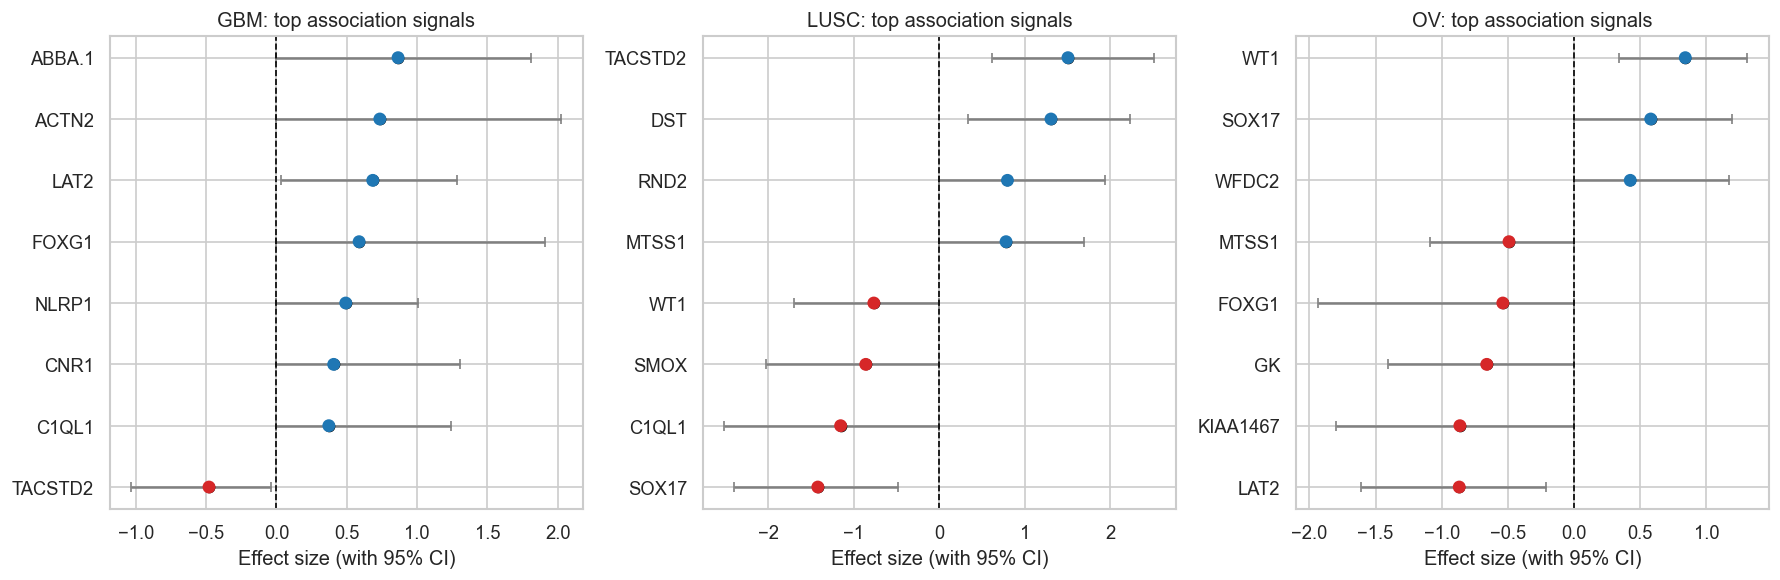

Interpretation: blue points support that class; red points point away from that class.


In [72]:
plot_df = consensus_df.copy()
plot_df = plot_df.sort_values(["class", "abs_effect"], ascending=[True, False]).groupby("class").head(8)

classes_sorted = sorted(plot_df["class"].unique())
fig, axes = plt.subplots(1, len(classes_sorted), figsize=(5 * len(classes_sorted), 5), sharex=False)
if len(classes_sorted) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes_sorted):
    sub = plot_df[plot_df["class"].eq(cls)].sort_values("effect")
    y_pos = np.arange(len(sub))
    x = sub["effect"].values
    xerr = np.vstack([x - sub["ci_low"].values, sub["ci_high"].values - x])

    colors = ["#1f77b4" if v >= 0 else "#d62728" for v in x]
    ax.errorbar(x, y_pos, xerr=xerr, fmt="o", color="black", ecolor="gray", capsize=3)
    ax.scatter(x, y_pos, c=colors, s=45, zorder=3)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["gene"].tolist())
    ax.set_title(f"{label_map_inv.get(int(cls), cls)}: top association signals")
    ax.set_xlabel("Effect size (with 95% CI)")

plt.tight_layout()
plt.show()
print("Interpretation: blue points support that class; red points point away from that class.")

In [74]:
# Predict new patients from example_patients.csv
example_path = Path("example_patients.csv")

if not example_path.exists():
    print("example_patients.csv was not found.")
    print("Please add patient rows, then re-run this cell.")
else:
    example_df = pd.read_csv(example_path)

    if id_col not in example_df.columns:
        raise ValueError(f"example_patients.csv must contain '{id_col}' column.")

    missing_genes = [g for g in X.columns if g not in example_df.columns]
    if missing_genes:
        raise ValueError(
            f"example_patients.csv is missing {len(missing_genes)} required genes. "
            f"Example: {missing_genes[:8]}"
        )

    X_example = example_df[X.columns].copy()

    pred_cancer = final_model.predict(X_example)

    X_example_vt = vt_causal.transform(X_example)
    X_example_sc = sc_causal.transform(X_example_vt)
    X_example_causal = skb_causal.transform(X_example_sc)
    X_example_causal_df = pd.DataFrame(X_example_causal, columns=causal_genes)

    svm_explain = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
    svm_explain.fit(X_base, y_causal.values)
    decision_scores = svm_explain.decision_function(X_example_causal)
    if np.ndim(decision_scores) == 1:
        confidence_margin = np.abs(decision_scores)
    else:
        sorted_scores = np.sort(decision_scores, axis=1)
        confidence_margin = sorted_scores[:, -1] - sorted_scores[:, -2]

    effect_lookup = consensus_df.set_index(["class", "gene"])["effect"].to_dict()
    class_gene_lists = (
        expanded_panel.sort_values(["class", "abs_effect"], ascending=[True, False])
        .groupby("class")["gene"]
        .apply(list)
        .to_dict()
)

    explanation_rows = []
    for i in range(len(example_df)):
        sid = str(example_df.iloc[i][id_col])
        pred_cls = int(pred_cancer[i])
        cls_name = label_map_inv.get(pred_cls, str(pred_cls))

        genes_for_class = class_gene_lists.get(pred_cls, [])[:6]
        contributions = []
        for g in genes_for_class:
            if g in X_example_causal_df.columns:
                x_val = float(X_example_causal_df.iloc[i][g])
                beta = float(effect_lookup.get((pred_cls, g), 0.0))
                contributions.append((g, x_val * beta))

        top3 = sorted(contributions, key=lambda t: abs(t[1]), reverse=True)[:3]
        top3_genes = [g for g, _ in top3]
        top3_text = ", ".join(top3_genes) if top3_genes else "no strong causal markers"

        if confidence_margin[i] >= 1.0:
            confidence_label = "higher-confidence pattern"
        elif confidence_margin[i] >= 0.4:
            confidence_label = "moderate-confidence pattern"
        else:
            confidence_label = "lower-confidence pattern"

        explanation = (
            f"Patient {sid}: predicted {cls_name}. "
            f"Main supportive biomarkers from the causal panel: {top3_text}. "
            f"This is a {confidence_label} (margin={confidence_margin[i]:.3f})."
        )

        explanation_rows.append({
            "id": sid,
            "predicted_cancer": pred_cls,
            "predicted_cancer_name": cls_name,
            "confidence_margin": float(confidence_margin[i]),
            "confidence_label": confidence_label,
            "top_causal_markers": top3_text,
            "doctor_explanation": explanation,
        })

    example_predictions_df = pd.DataFrame(explanation_rows)
    example_predictions_df.to_csv("example_patients_predictions_with_explanations.csv", index=False)

    display_df = example_predictions_df[[
        "id", "predicted_cancer_name", "confidence_label", "top_causal_markers", "doctor_explanation"
    ]].head(20)

    center_cols = ["id", "predicted_cancer_name", "confidence_label", "top_causal_markers"]
    left_cols = ["doctor_explanation"]
    col_pos = {col: i for i, col in enumerate(display_df.columns)}
    center_header_selectors = [f"th.col_heading.level0.col{col_pos[c]}" for c in center_cols]
    left_header_selectors = [f"th.col_heading.level0.col{col_pos[c]}" for c in left_cols]

    table_styles = [
        {"selector": "th", "props": [("white-space", "nowrap"), ("padding", "8px 12px")]},
        {"selector": "td", "props": [("white-space", "nowrap"), ("padding", "8px 12px")]},
    ]
    table_styles += [{"selector": s, "props": [("text-align", "center")]} for s in center_header_selectors]
    table_styles += [{"selector": s, "props": [("text-align", "left")]} for s in left_header_selectors]

    styled = (
        display_df.style
        .hide(axis="index")
        .set_properties(subset=center_cols, **{"text-align": "center", "white-space": "nowrap"})
        .set_properties(subset=left_cols, **{"text-align": "left", "white-space": "nowrap"})
        .set_table_styles(table_styles)
    )
    display(styled)

id,predicted_cancer_name,confidence_label,top_causal_markers,doctor_explanation
S1934300,OV,higher-confidence pattern,"LAT2, KIAA1467, WT1","Patient S1934300: predicted OV. Main supportive biomarkers from the causal panel: LAT2, KIAA1467, WT1. This is a higher-confidence pattern (margin=1.291)."
S4277303,GBM,higher-confidence pattern,"ABBA.1, ACTN2, FOXG1","Patient S4277303: predicted GBM. Main supportive biomarkers from the causal panel: ABBA.1, ACTN2, FOXG1. This is a higher-confidence pattern (margin=1.376)."
S1105960,LUSC,higher-confidence pattern,"TACSTD2, SOX17, DST","Patient S1105960: predicted LUSC. Main supportive biomarkers from the causal panel: TACSTD2, SOX17, DST. This is a higher-confidence pattern (margin=1.400)."
S5828168,GBM,higher-confidence pattern,"NLRP1, ABBA.1, FOXG1","Patient S5828168: predicted GBM. Main supportive biomarkers from the causal panel: NLRP1, ABBA.1, FOXG1. This is a higher-confidence pattern (margin=1.377)."
S7570807,OV,higher-confidence pattern,"WT1, KIAA1467, LAT2","Patient S7570807: predicted OV. Main supportive biomarkers from the causal panel: WT1, KIAA1467, LAT2. This is a higher-confidence pattern (margin=1.367)."
S6817087,OV,higher-confidence pattern,"WT1, LAT2, KIAA1467","Patient S6817087: predicted OV. Main supportive biomarkers from the causal panel: WT1, LAT2, KIAA1467. This is a higher-confidence pattern (margin=1.399)."
S5756417,OV,higher-confidence pattern,"WT1, LAT2, KIAA1467","Patient S5756417: predicted OV. Main supportive biomarkers from the causal panel: WT1, LAT2, KIAA1467. This is a higher-confidence pattern (margin=1.381)."
S7783735,GBM,higher-confidence pattern,"ACTN2, ABBA.1, FOXG1","Patient S7783735: predicted GBM. Main supportive biomarkers from the causal panel: ACTN2, ABBA.1, FOXG1. This is a higher-confidence pattern (margin=1.332)."
S2722520,GBM,higher-confidence pattern,"ABBA.1, NLRP1, LAT2","Patient S2722520: predicted GBM. Main supportive biomarkers from the causal panel: ABBA.1, NLRP1, LAT2. This is a higher-confidence pattern (margin=1.371)."
S2307116,OV,higher-confidence pattern,"WT1, KIAA1467, LAT2","Patient S2307116: predicted OV. Main supportive biomarkers from the causal panel: WT1, KIAA1467, LAT2. This is a higher-confidence pattern (margin=1.356)."


### Full-Dataset Cross-Validation
This section evaluates selected models using 5-fold stratified CV on the full training dataset (with preprocessing inside each fold) and summarizes fold-level accuracy patterns.

Full-data 5-fold CV results (RF/HistGBT excluded):
    model  cv_mean   cv_std  train_mean   time_s
    KNN-7 0.900686 0.012094    0.900395 4.360511
  SVM-RBF 0.900686 0.012094    0.900678 4.215280
   LogReg 0.876989 0.017905    0.917608 1.708714
LinearSVC 0.872469 0.014031    0.917890 2.934422


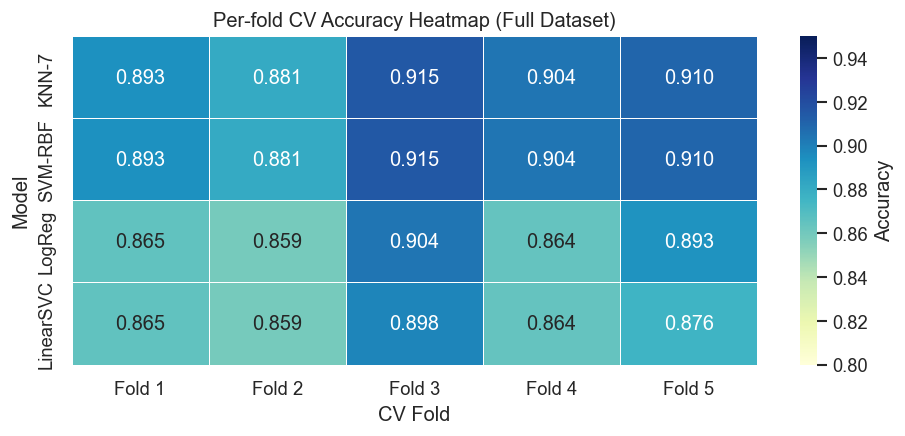

In [ ]:

df_full = pd.read_csv("train.csv")
X_full = df_full.drop(columns=["id", "cancer"])
y_full = df_full["cancer"]

cv_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    "KNN-7": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "SVM-RBF": SVC(kernel="rbf", random_state=42),
    "LogReg": LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42),
    "LinearSVC": LinearSVC(max_iter=5000, dual=True, random_state=42),
}

summary_rows = []
fold_scores = {}

for model_name, model in models_cv.items():
    pipe = Pipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=100)),
        ("clf", model),
    ])

    t0 = time()
    cv_res = cross_validate(
        pipe,
        X_full,
        y_full,
        cv=cv_full,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1,
    )
    elapsed = time() - t0

    fold_scores[model_name] = cv_res["test_score"]
    summary_rows.append({
        "model": model_name,
        "cv_mean": cv_res["test_score"].mean(),
        "cv_std": cv_res["test_score"].std(),
        "train_mean": cv_res["train_score"].mean(),
        "time_s": elapsed,
    })

res_fullcv_df = pd.DataFrame(summary_rows).sort_values("cv_mean", ascending=False)
print("Full-data 5-fold CV results (RF/HistGBT excluded):")
print(res_fullcv_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

heatmap_df = pd.DataFrame(fold_scores, index=[f"Fold {i}" for i in range(1, 6)]).T
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.80, vmax=0.95, linewidths=0.5, cbar_kws={"label": "Accuracy"}, ax=ax,
)
ax.set_title("Per-fold CV Accuracy Heatmap (Full Dataset)")
ax.set_xlabel("CV Fold")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

### CV Validation of Improvement Ideas
This section tests proposed next-step variants (feature size, SMOTE, and stacking) with the same CV protocol, then compares accuracy, macro-F1, and LUSC recall.

Cross-validated validation of NEXT STEPS:
                     model  cv_acc_mean  cv_acc_std  cv_f1_macro_mean  lusc_recall_cv
SVM + ANOVA-100 (baseline)     0.900686    0.012094          0.868416        0.653846
     Stacking (SVM+RF+KNN)     0.900686    0.012094          0.868416        0.653846
           SVM + ANOVA-500     0.899556    0.013966          0.865822        0.646154
   SMOTE + SVM + ANOVA-500     0.899556    0.013966          0.865822        0.646154
          SVM + ANOVA-1000     0.897296    0.017980          0.862734        0.646154


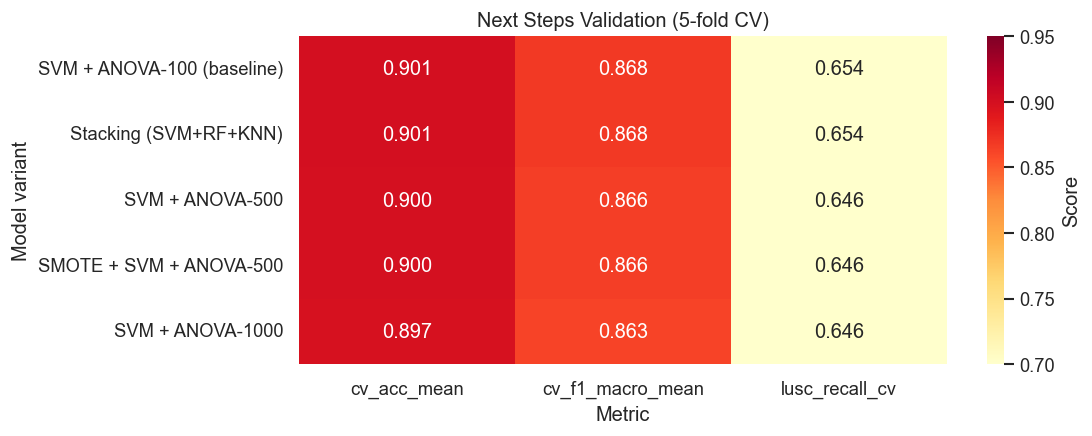

In [ ]:
# This cell is self-contained.
df_full = pd.read_csv("train.csv")
X_full = df_full.drop(columns=["id", "cancer"])
y_full = df_full["cancer"]

cv_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"acc": "accuracy", "f1_macro": "f1_macro"}

next_step_models = {
    "SVM + ANOVA-100 (baseline)": Pipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=100)),
        ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
    ]),
    "SVM + ANOVA-500": Pipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=500)),
        ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
    ]),
    "SVM + ANOVA-1000": Pipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=1000)),
        ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
    ]),
    "SMOTE + SVM + ANOVA-500": ImbPipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=500)),
        ("smote", SMOTE(random_state=42)),
        ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
    ]),
    "Stacking (SVM+RF+KNN)": Pipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=500)),
        ("clf", StackingClassifier(
            estimators=[
                ("svm", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)),
                ("knn", KNeighborsClassifier(n_neighbors=7, n_jobs=-1)),
            ],
            final_estimator=LogisticRegression(max_iter=2000, random_state=42),
            cv=3,
            n_jobs=-1,
        )),
    ]),
}

rows = []
for name, est in next_step_models.items():
    cv_res = cross_validate(est, X_full, y_full, cv=cv_full, scoring=scoring, n_jobs=-1)
    y_pred_cv = cross_val_predict(est, X_full, y_full, cv=cv_full, n_jobs=-1)
    lusc_recall = recall_score(y_full, y_pred_cv, labels=[2], average=None)[0]

    rows.append({
        "model": name,
        "cv_acc_mean": cv_res["test_acc"].mean(),
        "cv_acc_std": cv_res["test_acc"].std(),
        "cv_f1_macro_mean": cv_res["test_f1_macro"].mean(),
        "lusc_recall_cv": lusc_recall,
    })

next_steps_cv_df = pd.DataFrame(rows).sort_values("cv_acc_mean", ascending=False)
print("Cross-validated validation of NEXT STEPS:")
print(next_steps_cv_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

plt.figure(figsize=(9.5, 3.8))
plot_df = next_steps_cv_df.set_index("model")[["cv_acc_mean", "cv_f1_macro_mean", "lusc_recall_cv"]]
sns.heatmap(plot_df, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0.70, vmax=0.95, cbar_kws={"label": "Score"})
plt.title("Next Steps Validation (5-fold CV)")
plt.xlabel("Metric")
plt.ylabel("Model variant")
plt.tight_layout()
plt.show()

### SHAP-Based Sample Explanations
This section fits a tree-based model on the full data and uses SHAP to report globally important genes and top gene contributions for an individual sample prediction.

Top genes by mean absolute SHAP value (focus on class 2/LUSC when available):
   gene  mean_abs_shap
  KCNQ2       0.016290
 CDK5R1       0.009156
     GK       0.008162
  OLIG2       0.008120
  MTSS1       0.007614
   CNR1       0.007438
   RTN4       0.006751
  ADCY2       0.006325
PCDHGC3       0.006256
   LCAT       0.006076
 SPTBN1       0.005968
    DBI       0.005752
 BCAP29       0.004725
 ABBA.1       0.004695
 KCTD17       0.004587

Per-sample explanation (sample index 0) - top 10 drivers:
   gene  shap_value
  KCNQ2   -0.021036
  OLIG2   -0.012942
   CNR1   -0.012252
   LCAT   -0.011092
  VAMP5    0.009900
   SCG2    0.008684
 SORBS1   -0.007565
  ADCY2   -0.007379
CCDC103   -0.007166
 BCAP29    0.006772


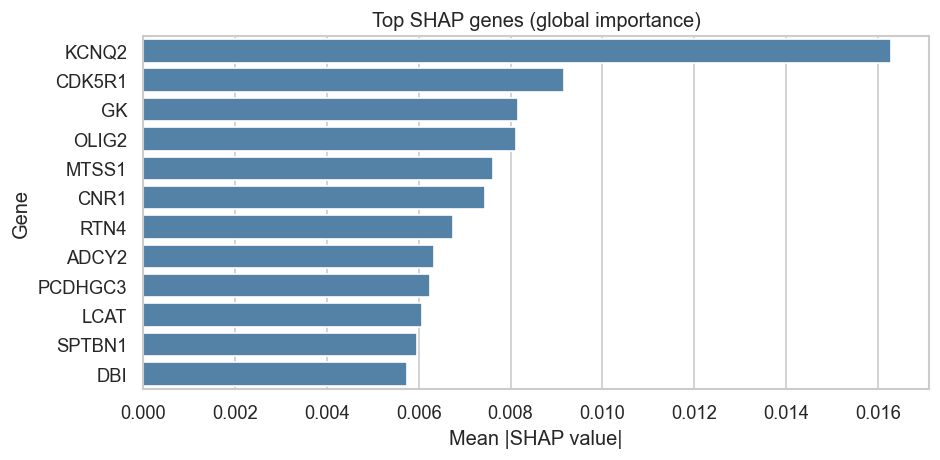

In [ ]:
try:
    import shap
except ImportError:
    print("SHAP is not installed. Run: pip install shap")
    shap = None

if shap is not None:
    shap_pipe = Pipeline([
        ("vt", VarianceThreshold(threshold=0.5)),
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=500)),
        ("clf", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)),
    ])

    shap_pipe.fit(X_full, y_full)
    X_proc = shap_pipe[:-1].transform(X_full)
    clf = shap_pipe.named_steps["clf"]
    vt_mask = shap_pipe.named_steps["vt"].get_support()
    vt_feature_names = np.array(X_full.columns)[vt_mask]
    anova_mask = shap_pipe.named_steps["anova"].get_support()
    selected_genes = vt_feature_names[anova_mask]

    X_proc_df = pd.DataFrame(X_proc, columns=selected_genes)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_proc_df)
    if isinstance(shap_values, list):
        class_labels = clf.classes_.tolist()
        class_idx = class_labels.index(2) if 2 in class_labels else 0
        sv = shap_values[class_idx]
    elif getattr(shap_values, "ndim", 0) == 3:
        class_labels = clf.classes_.tolist()
        class_idx = class_labels.index(2) if 2 in class_labels else 0
        sv = shap_values[:, :, class_idx]
    else:
        sv = shap_values

    mean_abs = np.abs(sv).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:15]
    shap_top = pd.DataFrame({
        "gene": np.array(selected_genes)[top_idx],
        "mean_abs_shap": mean_abs[top_idx],
    })

    print("Top genes by mean absolute SHAP value (focus on class 2/LUSC when available):")
    print(shap_top.to_string(index=False))

    sample_i = 0
    sample_contrib = pd.DataFrame({
        "gene": selected_genes,
        "shap_value": sv[sample_i],
        "abs_shap": np.abs(sv[sample_i]),
    }).sort_values("abs_shap", ascending=False).head(10)

    print(f"\nPer-sample explanation (sample index {sample_i}) - top 10 drivers:")
    print(sample_contrib[["gene", "shap_value"]].to_string(index=False))

    plt.figure(figsize=(8, 4))
    sns.barplot(data=shap_top.head(12), x="mean_abs_shap", y="gene", color="steelblue")
    plt.title("Top SHAP genes (global importance)")
    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Gene")
    plt.tight_layout()
    plt.show()